In [12]:
# Import necessary libraries
import pandas as pd  # For loading and handling the dataset
from sklearn.model_selection import train_test_split  # For splitting the data into train and test sets
from sklearn.naive_bayes import GaussianNB  # Naïve Bayes classifier from sklearn
from sklearn.metrics import confusion_matrix, classification_report  # For calculating evaluation metrics
import matplotlib.pyplot as plt  # For visualizing confusion matrix
import seaborn as sns  # For heatmap visualization of the confusion matrix


In [13]:
# Step 1: Load the iris dataset from a local CSV file
# Make sure the iris.csv file is in the same directory as this script, or provide the full path.
df = pd.read_csv('iris.csv')
# Step 2: Inspect the dataset to ensure it has the expected columns
# Print the first few rows to check the structure of the dataset
print(df.head())

   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa


In [14]:
# Step 3: Prepare the data by splitting it into features (X) and target (y)
# We are separating the features (input variables) and the target (output variable 'variety')
X = df.drop("variety", axis=1)  # Features (all columns except 'variety')
y = df["variety"]  # Target (variety)

In [15]:
# Step 4: Split the data into training and testing sets
# 80% of the data will be used for training, and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Step 5: Initialize and train the Naïve Bayes model
# Here, we are using Gaussian Naïve Bayes as it is suitable for continuous features (like those in the iris dataset)
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)  # Training the model with the training data

GaussianNB()

In [17]:
# Step 6: Make predictions on the test set
# We now use the trained model to predict the species of the flowers in the test set
y_pred = nb_classifier.predict(X_test)


In [19]:
# Step 7: Evaluate the model using a confusion matrix and classification report
# The confusion matrix helps us understand how many predictions were correct and incorrect for each class
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
# The classification report provides precision, recall, and f1-score for each class
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       1.00      1.00      1.00         9
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [20]:
# Step 8: Extract metrics (True Positives, False Positives, True Negatives, False Negatives) from the confusion matrix
# Here, we are extracting values from the confusion matrix for the first class ('setosa').
TP = cm[0, 0]  # True Positives for 'setosa'
FP = cm[0, 1]  # False Positives for 'setosa'
TN = cm[1, 1]  # True Negatives for 'setosa'
FN = cm[1, 0]  # False Negatives for 'setosa'


In [21]:
# Step 9: Calculate additional evaluation metrics
# Now we calculate accuracy, error rate, precision, and recall based on the confusion matrix values
accuracy = (TP + TN) / (TP + FP + TN + FN)  # Proportion of correct predictions
error_rate = (FP + FN) / (TP + FP + TN + FN)  # Proportion of incorrect predictions
precision = TP / (TP + FP)  # How many of the predicted positive results were actually positive
recall = TP / (TP + FN)  # How many of the actual positive results were predicted correctly

In [22]:
# Step 10: Print out the metrics for better understanding
print(f"Accuracy: {accuracy}")
print(f"Error Rate: {error_rate}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")


Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


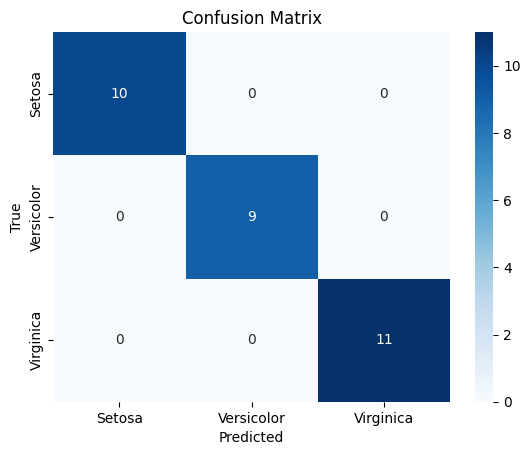

In [23]:
# Step 11: (Optional) Visualize the Confusion Matrix
# Create a heatmap to visually represent the confusion matrix for better interpretation
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df['variety'].unique(), yticklabels=df['variety'].unique())
plt.xlabel('Predicted')  # Label for the x-axis
plt.ylabel('True')  # Label for the y-axis
plt.title('Confusion Matrix')  # Title for the plot
plt.show()  # Display the plot